# <a id='toc1_'></a>[Basic Root Locus design](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Basic Root Locus design](#toc1_)    
  - [Design 9-17](#toc1_1_)    
  - [Design 9-25](#toc1_2_)    
  - [Design 9-28 Pole Placement](#toc1_3_)    
  - [Design 9-22 RL design using angles and pole/zero cancellation](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [54]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import sympy as sp

import control as ct
import control.matlab as cmat

from IPython.display import display, Latex

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## <a id='toc1_1_'></a>[Design 9-17](#toc0_)

Closed Loop Poles at: -20.25+0.00j, -1.00+2.00j, -1.00-2.00j


<IPython.core.display.Math object>

<IPython.core.display.Latex object>

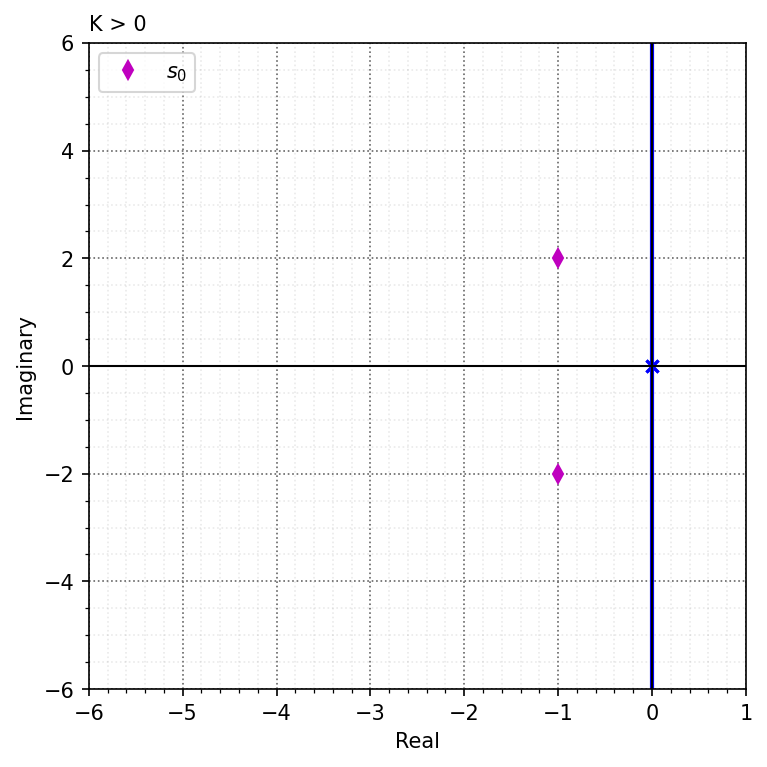

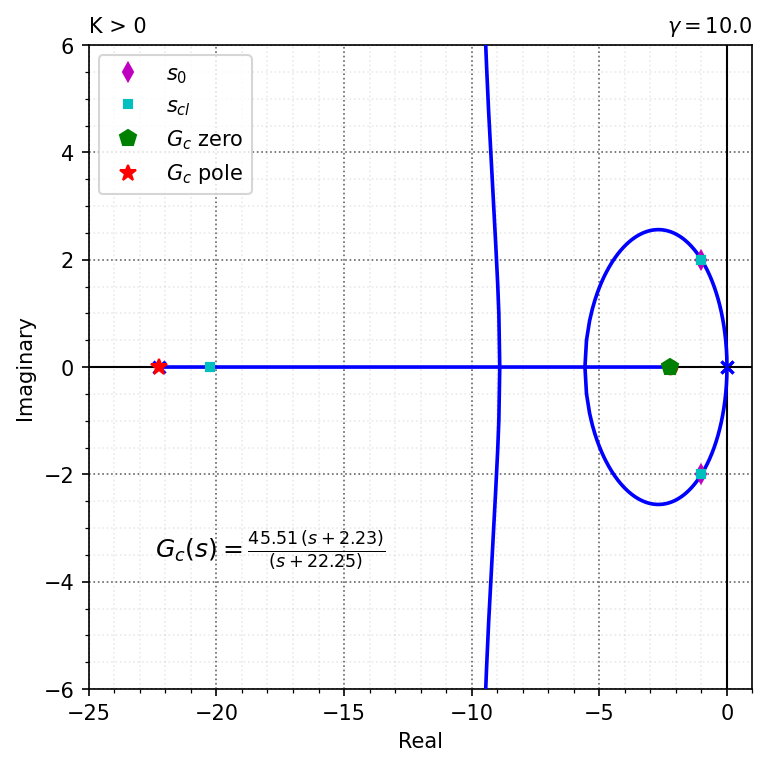

In [55]:
s_target = complex(-1,2)
gamma = 10 # p/z ratio

G = ct.tf((0,1), np.convolve((1,0),(1,0)))
Gc, scl, info_9_17 = cm.Root_Locus_design_ratio(G,s_target = s_target, gamma = gamma,verbose=True)
L = G*Gc

# Gain only design
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(G,np.logspace(-3, 100, num=1500),verbose=True)
ct.rlocus(G, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8,label=r'$s_0$')
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.set_xlim((-6,1))
ax.set_ylim([-6, 6])
plt.xlabel('Real')
plt.ylabel('Imaginary')

bm.nicegrid(ax)
unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())
plt.title('K > 0',loc='left')
plt.savefig("./figs/Ex9_17a.pdf", dpi=600)

# Compensator design
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(L,np.logspace(-3, 1, num=1500),verbose=True)
ct.rlocus(L, gains=klist,color='b',ax=ax)

ax.plot(s_target.real,s_target.imag,'md',ms=8,label=r'$s_0$')
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=4,label=r'$s_{cl}$')
ax.plot(scl.real,-scl.imag,'cs',ms=4)
plt.xlabel('Real'); plt.ylabel('Imaginary')
plt.title('K > 0',loc='left')
plt.title(r'$\gamma={:3.1f}$'.format(gamma),loc='right')
ax.plot(np.real(Gc.zeros()), np.imag(Gc.zeros()), color='green', marker='p', ms=8, ls = "None", label=r'$G_c$ zero',zorder=100)
ax.plot(np.real(Gc.poles()), np.imag(Gc.poles()), color='red', marker='*', ls = "None", ms=8, label=r'$G_c$ pole',zorder=100)

msgs = cm.show_tf_latex(Gc,factor=True,sigfigs=2,name='G_c(s)')
ax.text(0.1,0.25,msgs,transform=ax.transAxes, fontsize=12, verticalalignment='top')

ax.set_xlim((-(np.ceil(-np.real(Gc.poles())[0] / 5) * 5), 1))
ax.set_ylim([-6, 6])

bm.nicegrid(ax)
unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())
plt.savefig("./figs/Ex9_17.pdf", dpi=600)
print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))
cm.show_tf_latex(Gc,show=True,factor=True,sigfigs=2,name='G_c(s)')
display(Latex(info_9_17.info))

## <a id='toc1_2_'></a>[Design 9-25](#toc0_)

Phase from G -243.43
Phase from Gc zero 90.00
Phase required 26.57
Closed Loop Poles at: -4.00+0.00j, -2.00+2.00j, -2.00-2.00j


<IPython.core.display.Math object>

<IPython.core.display.Latex object>

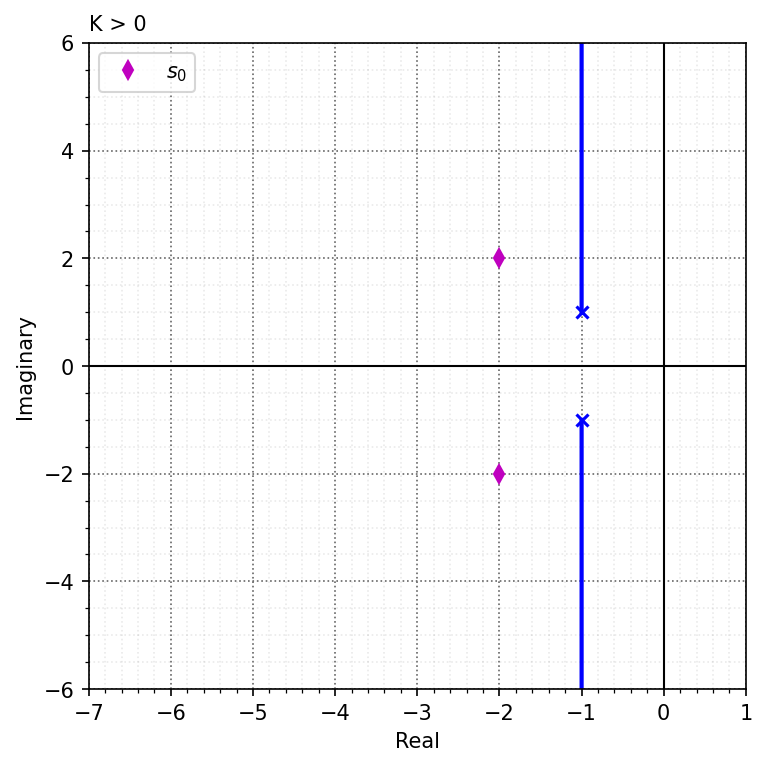

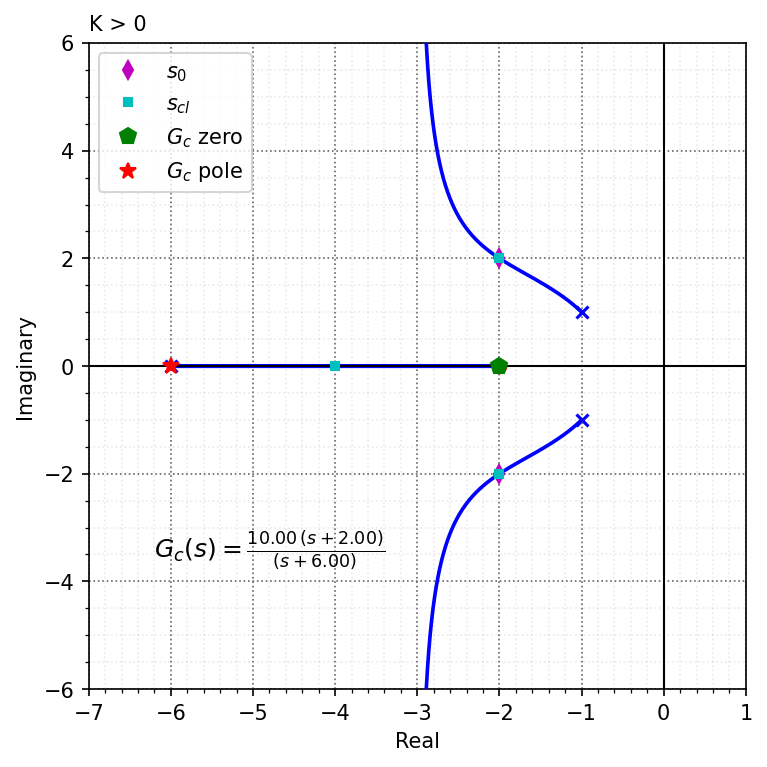

In [56]:
s_target=complex(-2,2)
#
G = ct.tf((0,1), (1,2,2))
Gc, scl,info_9_25 = cm.Root_Locus_design_cancel(G,s_cancel = -2, s_target = s_target,verbose=True)
L = G*Gc

# Gain only design
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(G)
rl = ct.rlocus(G, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8,label=r'$s_0$')
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
plt.xlim((-7,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
plt.xlabel('Real')
plt.ylabel('Imaginary')

unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())
bm.nicegrid(ax)
plt.savefig("./figs/Ex9_25a.pdf", dpi=600)

# With Compensator designed
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(L)
rl = ct.rlocus(L, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8,label=r'$s_0$')
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=4,label=r'$s_{cl}$')
plt.xlim((-7,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
plt.xlabel('Real')
plt.ylabel('Imaginary')

msgs = cm.show_tf_latex(Gc,factor=True,sigfigs=2,name='G_c(s)')
ax.text(0.1,0.25,msgs,transform=ax.transAxes, fontsize=12, verticalalignment='top')

ax.plot(np.real(Gc.zeros()), np.imag(Gc.zeros()), color='green', marker='p', ms=8, ls = "None", label=r'$G_c$ zero',zorder=100)
ax.plot(np.real(Gc.poles()), np.imag(Gc.poles()), color='red', marker='*', ls = "None", ms=8, label=r'$G_c$ pole',zorder=100)

bm.nicegrid(ax)
unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())
plt.savefig("./figs/Ex9_25.pdf", dpi=600)

print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))
cm.show_tf_latex(Gc,show=True,factor=True,sigfigs=2,name='G_c(s)')

def writefile(filename, Gc):
    with open(filename+"_zero.txt", "w") as f:
        f.write(str(f"{np.real(Gc.zeros())[0]:4.2f}"))
    with open(filename+"_pole.txt", "w") as f:
        f.write(str(f"{np.real(Gc.poles())[0]:4.2f}"))
    with open(filename+"_gain.txt", "w") as f:
        gain = Gc.num[0][0]/Gc.den[0][0]
        f.write(str(f"{gain[0]:4.2f}"))

source = "./"        
cm.writeGc(source+"Gc_9_25", Gc)
display(Latex(info_9_25.info))

## <a id='toc1_3_'></a>[Design 9-28 Pole Placement](#toc0_)

Closed Loop Poles at: -1.00+2.00j, -1.00-2.00j, -0.25+0.00j


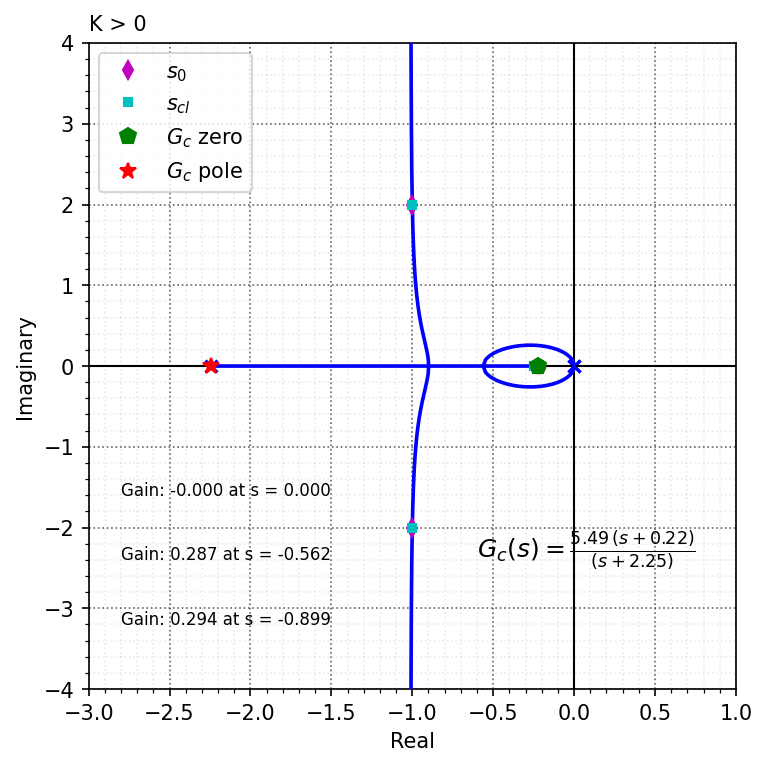

In [57]:
#System
G = ct.tf((0,1), (1,0,0))
#Pole Placement
s_targ = complex(-1,2)

from sympy import symbols, solve
Ks,alps,zs,ps = symbols('K alp z p')

gamma = 10
ps = gamma*zs

# closed-loop char eq will be desired poles and alp, which is unknown
phi_d = np.convolve(np.convolve((1,-s_targ),(1,np.conjugate(-s_targ))),(1,alps))
# form L_den+KL_num to find actual char eq
phi_c = np.convolve(np.squeeze(G.den),[1,ps]) + Ks*np.convolve(np.squeeze(G.num),(0,0,1,zs))

# equate the two char eq and solve for the parms of the controller
func = [phi_d[x]-phi_c[x] for x in range(1,4)]
sol = solve(func,(zs,alps,Ks))
sol_z, sol_alp, sol_K = [float(sol[0][x]) for x in range(len(sol[0]))]

Gc = sol_K * ct.tf((1,sol_z), (1,gamma*sol_z))
L = G*Gc
Gcl = ct.feedback(L,1)
scl = Gcl.poles()
print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(L, verbose=True)
rl = ct.rlocus(L, gains=klist, color='b', ax=ax)
ax.plot(np.real(s_targ),np.imag(s_targ),'md',ms=8,label=r'$s_0$')
ax.plot(np.real(s_targ),np.imag(-s_targ),'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=4,label=r'$s_{cl}$')
ax.set_xlim([-3, 1]);ax.set_ylim([-4, 4])
plt.xlabel('Real');plt.ylabel('Imaginary')
ax.set_title('K > 0',loc='left')
cm.add_break_info(ax, break_info)

msgs = cm.show_tf_latex(Gc,factor=True,sigfigs=2,name='G_c(s)')
ax.text(0.6,0.25,msgs,transform=ax.transAxes, fontsize=12, verticalalignment='top')

ax.plot(np.real(Gc.zeros()), np.imag(Gc.zeros()), color='green', marker='p', ms=8, ls = "None", label=r'$G_c$ zero',zorder=100)
ax.plot(np.real(Gc.poles()), np.imag(Gc.poles()), color='red', marker='*', ls = "None", ms=8, label=r'$G_c$ pole',zorder=100)

bm.nicegrid(ax)
unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())

plt.savefig("./figs/Ex9_24.pdf", dpi=600)

with open(source+"Gc_9_24_zero.txt", "w") as f:
    f.write(str(f"{np.real(Gc.zeros())[0]:4.2f}"))
with open(source+"Gc_9_24_pole.txt", "w") as f:
    f.write(str(f"{np.real(Gc.poles())[0]:4.2f}"))
with open(source+"Gc_9_24_gain.txt", "w") as f:
    gain = Gc.num[0][0]/Gc.den[0][0]
    f.write(str(f"{gain[0]:4.2f}"))
    

## <a id='toc1_4_'></a>[Design 9-22 RL design using angles and pole/zero cancellation](#toc0_)

Phase from G -206.57
Phase from Gc zero 90.00
Phase required 63.43
Closed Loop Poles at: -1.00+2.00j, -1.00-2.00j, -1.00+0.00j


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

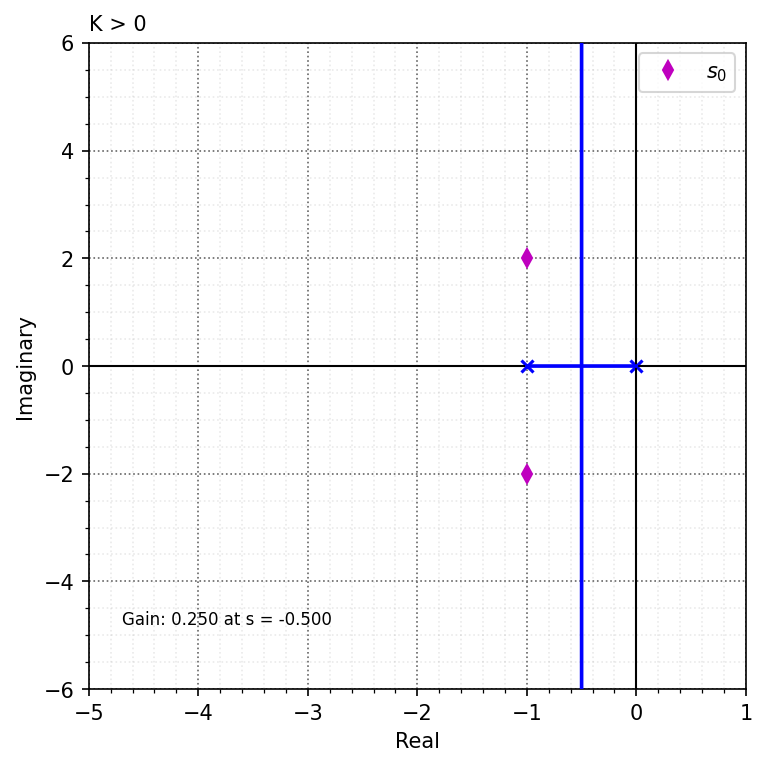

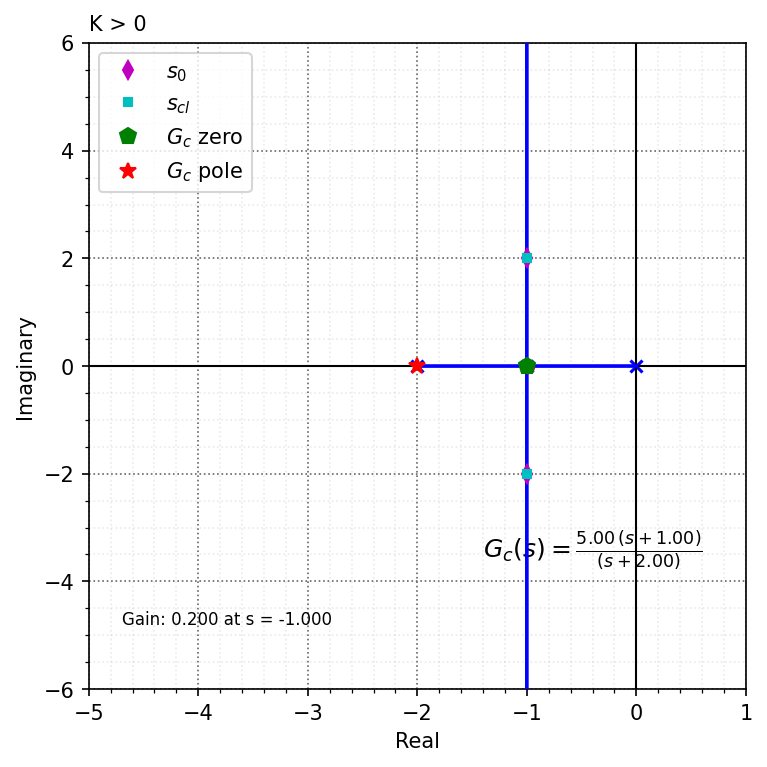

In [58]:
# G_c(s) = K(s+z)/(s+p)

G = ct.tf((0,1), np.convolve((1,0),(1, 1)))
s_target = complex(-1,2)

Gc, scl,info_9_22 = cm.Root_Locus_design_cancel(G,s_target = s_target, verbose=True)
L = G*Gc
print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))
cm.show_tf_latex(G,"G",show=True,factor=True,sigfigs=2,name='G(s)')
cm.show_tf_latex(Gc,"Gc",show=True,factor=True,sigfigs=2,name='G_c(s)')

###################
# G
###################
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(G,verbose=True)
rl = ct.rlocus(G, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8,label=r'$s_0$')
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.set_xlim((-5,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
bm.nicegrid(ax)
cm.add_break_info(ax, break_info)
unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.savefig("./figs/Ex9_22a.pdf", dpi=600)

###################
# L
###################
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(L, verbose=True)    
rl = ct.rlocus(L, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',label=r'$s_0$',ms=8)
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=3,label=r'$s_{cl}$')
ax.set_xlim((-5,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
cm.add_break_info(ax, break_info)
msgs = cm.show_tf_latex(Gc,factor=True,sigfigs=2,name='G_c(s)')
ax.text(0.6,0.25,msgs,transform=ax.transAxes, fontsize=12, verticalalignment='top')

ax.plot(np.real(Gc.zeros()), np.imag(Gc.zeros()), color='green', marker='p', ms=8, ls = "None", label=r'$G_c$ zero',zorder=100)
ax.plot(np.real(Gc.poles()), np.imag(Gc.poles()), color='red', marker='*', ls = "None", ms=8, label=r'$G_c$ pole',zorder=100)

plt.xlabel('Real');plt.ylabel('Imaginary')
bm.nicegrid(ax)
unique = cm.color_rl(ax,verbose=True)
ax.legend(unique.values(), unique.keys())
plt.savefig("./figs/Ex9_22.pdf", dpi=600)
display(Latex(info_9_22.info))